In [9]:
import os

os.makedirs("docs", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("outputs/visuals", exist_ok=True)

print("✅ Folders created: docs/, data/processed/, outputs/visuals/")


✅ Folders created: docs/, data/processed/, outputs/visuals/


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [11]:
RAW_CSV = "customer_support_tickets.csv"  # keep your csv in same folder as notebook

df = pd.read_csv(RAW_CSV)
print("✅ Loaded:", df.shape)
df.head()


✅ Loaded: (8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [13]:
# Schema
schema = pd.DataFrame({
    "Column": df.columns,
    "dtype": df.dtypes.astype(str),
    "missing_values": df.isna().sum().values,
    "missing_%": (df.isna().mean() * 100).round(2).values
}).sort_values("missing_values", ascending=False)

schema
schema.to_csv("docs/schema_missing_report.csv", index=False)
print("✅ Saved: docs/schema_missing_report.csv")


✅ Saved: docs/schema_missing_report.csv


In [14]:
def safe_counts(col):
    if col in df.columns:
        return df[col].astype(str).value_counts().head(20)
    return f"Column '{col}' not found"

print("Ticket Type:\n", safe_counts("Ticket Type"), "\n")
print("Ticket Priority:\n", safe_counts("Ticket Priority"), "\n")
print("Product Purchased (Category):\n", safe_counts("Product Purchased"), "\n")
print("Ticket Status:\n", safe_counts("Ticket Status"), "\n")
with open("docs/initial_kpi_snapshot.txt", "w", encoding="utf-8") as f:
    f.write("Initial KPI Snapshot\n\n")
    for col in ["Ticket Type","Ticket Priority","Product Purchased","Ticket Status"]:
        f.write(f"\n--- {col} ---\n")
        if col in df.columns:
            f.write(df[col].astype(str).value_counts().to_string())
        else:
            f.write("NOT FOUND")
print("✅ Saved: docs/initial_kpi_snapshot.txt")


Ticket Type:
 Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64 

Ticket Priority:
 Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64 

Product Purchased (Category):
 Product Purchased
Canon EOS                         240
GoPro Hero                        228
Nest Thermostat                   225
Amazon Echo                       221
Philips Hue Lights                221
LG Smart TV                       219
Sony Xperia                       217
Roomba Robot Vacuum               216
Apple AirPods                     213
LG OLED                           213
iPhone                            212
Sony 4K HDR TV                    210
LG Washing Machine                208
Garmin Forerunner                 208
Canon DSLR Camera                 206
Nikon D                           204
Nintendo Switc

In [15]:
df_clean = df.drop_duplicates().copy()

# clean column names
df_clean.columns = [c.strip() for c in df_clean.columns]

# strip text fields
for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    df_clean[col] = df_clean[col].replace("nan", np.nan)

# fill important missing text columns
for col in ["Ticket Type", "Ticket Priority", "Product Purchased", "Ticket Status"]:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("Unknown")

print("✅ Clean done:", df_clean.shape)
df_clean.head()


✅ Clean done: (8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [16]:
priority_map = {"critical": 4, "high": 3, "medium": 2, "low": 1}

if "Ticket Priority" in df_clean.columns:
    df_clean["Priority_Score"] = (
        df_clean["Ticket Priority"].astype(str).str.lower().map(priority_map).fillna(0).astype(int)
    )
else:
    print("Ticket Priority column missing; Priority_Score not created.")
for col in ["First Response Time", "Time to Resolution"]:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")

if "First Response Time" in df_clean.columns and "Time to Resolution" in df_clean.columns:
    df_clean["Resolution_Duration_Hours"] = (
        (df_clean["Time to Resolution"] - df_clean["First Response Time"]).dt.total_seconds() / 3600
    )
else:
    print("Time columns missing; Resolution_Duration_Hours not created.")
    
df_clean[["Ticket Priority","Priority_Score","Resolution_Duration_Hours"]].head(10)


,Ticket Priority,Priority_Score,Resolution_Duration_Hours
0,Critical,4,NaN
1,Critical,4,NaN
2,Low,1,6.850000
3,Low,1,-5.533333
4,Low,1,19.683333
5,Low,1,NaN
6,Critical,4,NaN
7,Critical,4,NaN
8,Low,1,NaN
9,Critical,4,NaN


In [17]:
clean_path = "data/processed/cleaned_tickets.csv"
df_clean.to_csv(clean_path, index=False)
print("✅ Saved cleaned dataset:", clean_path)


✅ Saved cleaned dataset: data/processed/cleaned_tickets.csv


In [18]:
# Data dictionary
dd = pd.DataFrame({"Column": df_clean.columns, "dtype": df_clean.dtypes.astype(str)})
dd.to_csv("docs/data_dictionary.csv", index=False)

# Feature summary
with open("docs/feature_engineering_summary.md", "w", encoding="utf-8") as f:
    f.write("# Feature Engineering Summary (Milestone 1)\n\n")
    f.write("## Cleaning\n")
    f.write("- Dropped duplicates\n")
    f.write("- Stripped whitespace in text columns\n")
    f.write("- Filled missing values for key text fields with 'Unknown'\n\n")
    f.write("## New Features\n")
    f.write("- Priority_Score: Critical=4, High=3, Medium=2, Low=1\n")
    f.write("- Resolution_Duration_Hours: (Time to Resolution - First Response Time) in hours\n")

print("✅ Saved docs: docs/data_dictionary.csv, docs/feature_engineering_summary.md")


✅ Saved docs: docs/data_dictionary.csv, docs/feature_engineering_summary.md


In [19]:
df_viz = pd.read_csv("data/processed/cleaned_tickets.csv")
print(df_viz.shape)


(8469, 19)


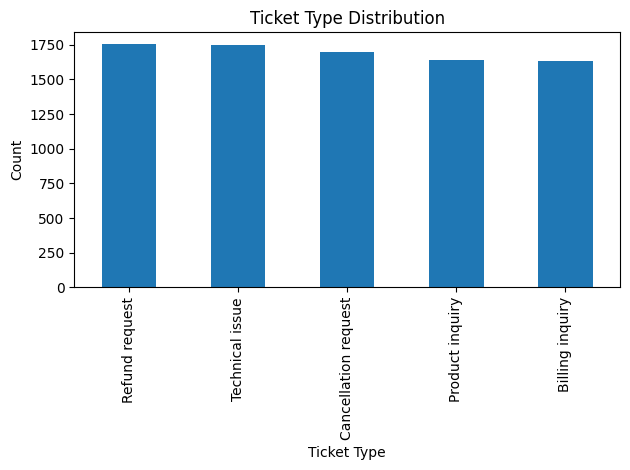

In [20]:
type_counts = df_viz["Ticket Type"].value_counts()
type_counts.plot(kind="bar")
plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/visuals/ticket_type_distribution.png", dpi=200)
plt.show()


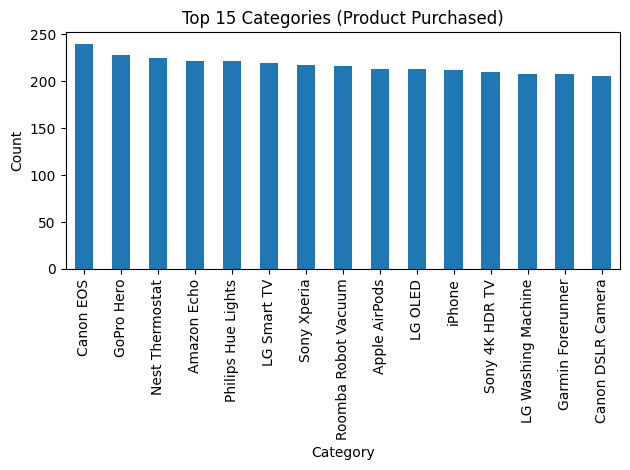

In [21]:
top_cats = df_viz["Product Purchased"].value_counts().head(15)
top_cats.plot(kind="bar")
plt.title("Top 15 Categories (Product Purchased)")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/visuals/top_categories.png", dpi=200)
plt.show()


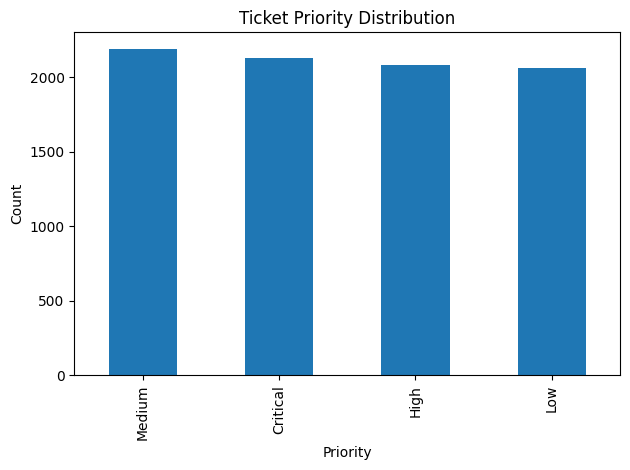

In [22]:
priority_counts = df_viz["Ticket Priority"].value_counts()
priority_counts.plot(kind="bar")
plt.title("Ticket Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/visuals/priority_distribution.png", dpi=200)
plt.show()


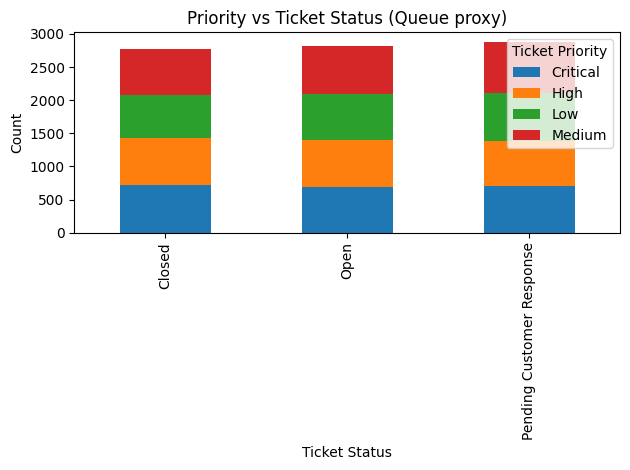

In [23]:
pt = pd.crosstab(df_viz["Ticket Status"], df_viz["Ticket Priority"])
pt.plot(kind="bar", stacked=True)
plt.title("Priority vs Ticket Status (Queue proxy)")
plt.xlabel("Ticket Status")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/visuals/priority_vs_status.png", dpi=200)
plt.show()


In [24]:
with open("docs/week3_module3_summary.md", "w", encoding="utf-8") as f:
    f.write("# Week 3 – Module 3: Exploratory Visualization\n\n")
    f.write("## Outputs\n")
    f.write("- outputs/visuals/ticket_type_distribution.png\n")
    f.write("- outputs/visuals/top_categories.png\n")
    f.write("- outputs/visuals/priority_distribution.png\n")
    f.write("- outputs/visuals/priority_vs_status.png\n\n")
    f.write("## Notes\n")
    f.write("- Ticket Status used as a queue/progress proxy (Open/Pending/Closed).\n")
print("✅ Saved: docs/week3_module3_summary.md")


✅ Saved: docs/week3_module3_summary.md
